In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [9]:
df=pd.read_csv("/content/cardekho_data.csv")

In [10]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [11]:
df.shape

(301, 9)

In [12]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [13]:
df=pd.get_dummies(df,drop_first=True)

In [14]:
x=df.drop("Selling_Price",axis=1)
y=df["Selling_Price"]

In [15]:
df=pd.get_dummies(df,drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [17]:
from sklearn.tree import DecisionTreeRegressor
from sklearn import tree
model = DecisionTreeRegressor()
model.fit(x_train, y_train)

DecisionTreeRegressor()

In [18]:
model.score(x_test,y_test)

0.9450019827239933

In [19]:

model.score(x_train,y_train)

1.0

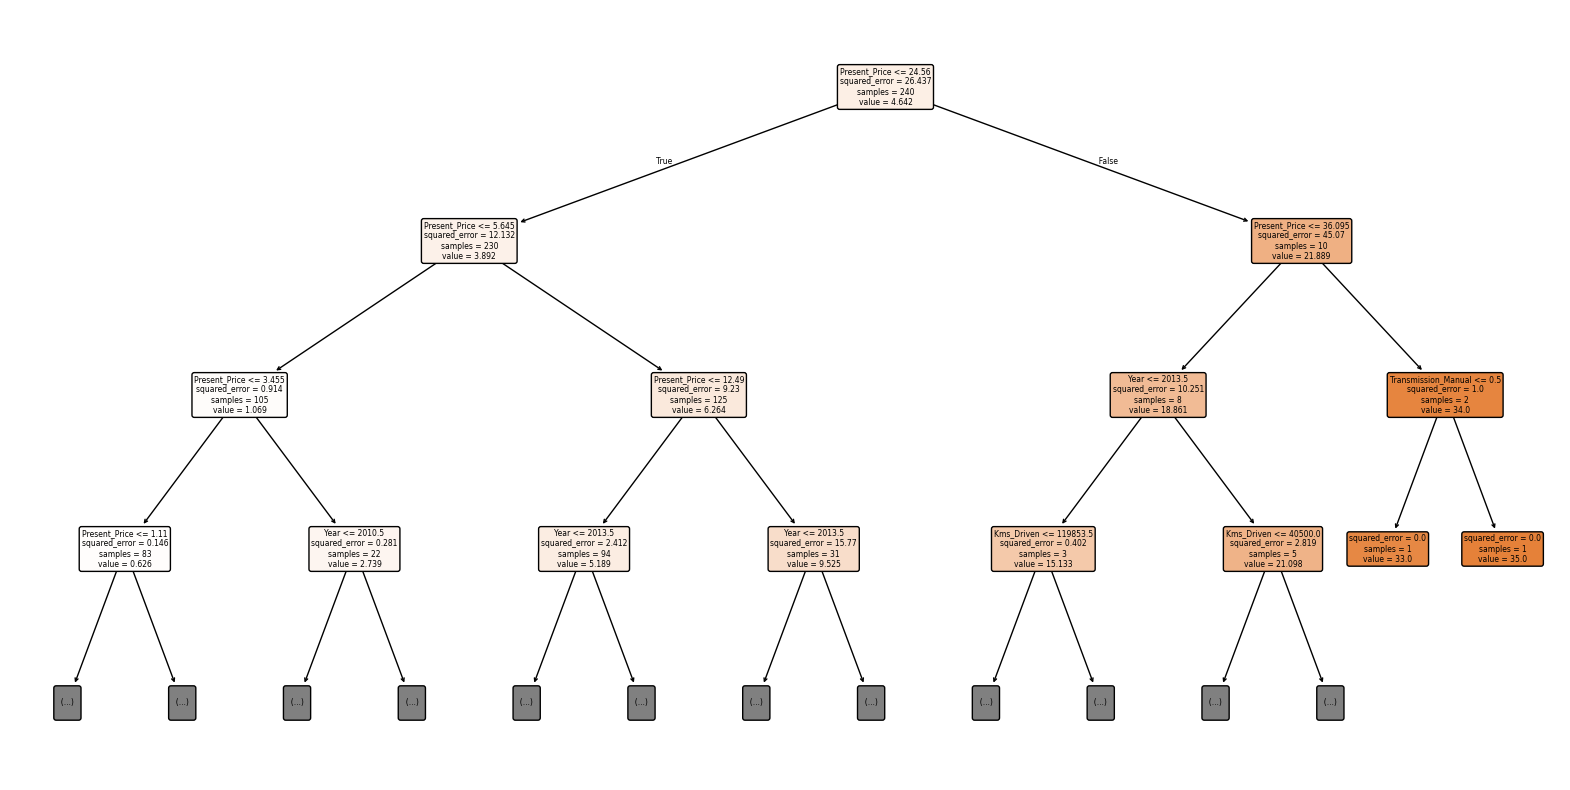

In [20]:
plt.figure(figsize=(20,10))
tree.plot_tree(model,
               feature_names=x.columns,
               filled=True,
               rounded=True,
               max_depth=3)

plt.savefig("decision_tree.png")

In [21]:

cart = DecisionTreeRegressor(
    criterion='squared_error',
    random_state=42,
    max_depth=5
)
cart.fit(x_train, y_train)
y_pred = cart.predict(x_test)
print("Train Score:", cart.score(x_train, y_train))
print("Test Score:", cart.score(x_test, y_test))

Train Score: 0.9760116546571069
Test Score: 0.9251138666185316


In [23]:
df=pd.read_csv("/content/breast-cancer-wisconsin-data_data.csv")

In [24]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [25]:
df.isnull().sum()


,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [29]:
df=df.drop(['Unnamed: 32'],axis =1)

In [38]:
x=df.drop("diagnosis_M",axis=1)
y=df["diagnosis_M"].astype(int)

In [40]:
df=pd.get_dummies(df,drop_first=True)


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)
id3 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
id3.fit(x_train, y_train)
print("Train Score:", id3.score(x_train, y_train))
print("Test Score:", id3.score(x_test, y_test))

Train Score: 1.0
Test Score: 0.956140350877193
